# The Price-Tag Decision: Logistic Regression and Menu Costs at SunCoast Retail Mart
ISM 6642 (MSIS) Assignment 6. Runs end-to-end from `data/retail_relabel.csv`.

Outputs:
- `outputs/figures/*.png`: every figure used in the write-up
- `outputs/tables/*.csv`: every table used in the write-up
- `outputs/results.json`: every number quoted in the write-up

Seeds: the train/test split uses `random_state = 7` as the assignment specifies. Nothing else in the
pipeline is random.

In [1]:
import json
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.metrics import (accuracy_score, confusion_matrix, precision_score, recall_score,
                             roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split

SEED = 7
BASE = Path.cwd()
DATA = BASE / "data" / "retail_relabel.csv"
FIG = BASE / "outputs" / "figures"
TAB = BASE / "outputs" / "tables"
FIG.mkdir(parents=True, exist_ok=True)
TAB.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 150, "font.size": 9, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.titlesize": 10, "axes.titleweight": "bold"})
C_PAPER, C_ESL, C_ACCENT, C_GREY = "#2E74B5", "#E07B39", "#1F3864", "#9AA5B1"

R = {}  # every number quoted in the write-up is collected here


def r(x, k=4):
    """Round numpy/pandas scalars to plain Python floats for JSON."""
    return round(float(x), k)

## Part 1: Feature engineering and EDA
- **CompAvg**: mean of the three competitor prices (BigBox Depot, ValueMart, QuickShop)
- **GapPct** = 100·(StorePrice − CompAvg)/CompAvg: signed gap (+ means the store is priced above competitors)
- **AbsGapPct** = |GapPct|: size of the misalignment, whatever its direction
- **LogUnits** = ln(WeeklyUnitsSold): velocity on a log scale (each doubling has the same effect)
- **MarginPct** = 100·(StorePrice − UnitCost)/StorePrice: gross margin on the current price

In [2]:
df = pd.read_csv(DATA)
COMP = ["Competitor_BigBoxDepot", "Competitor_ValueMart", "Competitor_QuickShop"]

df["CompAvg"] = df[COMP].mean(axis=1)
df["GapPct"] = 100 * (df["StorePrice"] - df["CompAvg"]) / df["CompAvg"]
df["AbsGapPct"] = df["GapPct"].abs()
df["LogUnits"] = np.log(df["WeeklyUnitsSold"])
df["MarginPct"] = 100 * (df["StorePrice"] - df["UnitCost"]) / df["StorePrice"]
df["TagType"] = np.where(df["ElectronicShelfLabel"] == 1, "ESL", "Paper")

print("Rows:", len(df), "| missing values:", int(df.isna().sum().sum()), "| duplicate SKUs:",
      int(df["SKU"].duplicated().sum()))
R["n"] = len(df)
R["missing"] = int(df.isna().sum().sum())

feat_desc = df[["CompAvg", "GapPct", "AbsGapPct", "LogUnits", "MarginPct", "CostChangePct",
                "UnitCost", "RelabelCost", "WeeklyUnitsSold", "DaysSinceLastChange"]].describe().T
feat_desc = feat_desc[["mean", "std", "min", "50%", "max"]].round(2)
feat_desc.to_csv(TAB / "feature_summary.csv")
print(feat_desc)
R["gap_mean"], R["gap_sd"] = r(df["GapPct"].mean(), 2), r(df["GapPct"].std(), 2)
R["absgap_mean"], R["absgap_median"] = r(df["AbsGapPct"].mean(), 2), r(df["AbsGapPct"].median(), 2)
R["share_over"] = r((df["GapPct"] > 0).mean())
R["margin_mean"] = r(df["MarginPct"].mean(), 2)

Rows: 1500 | missing values: 0 | duplicate SKUs: 0
                       mean     std    min     50%     max
CompAvg               19.35   25.38   1.58   10.32  184.76
GapPct                 3.62   12.73 -28.27    3.71   42.17
AbsGapPct             11.00    7.36   0.02   10.10   42.17
LogUnits               3.94    0.50   1.79    3.99    5.16
MarginPct             32.68    7.74  16.73   33.74   44.44
CostChangePct          1.66    3.98 -10.55    1.67   14.33
UnitCost              13.28   17.28   1.10    7.04  114.07
RelabelCost            1.03    0.82   0.02    0.98    2.50
WeeklyUnitsSold       57.64   26.79   6.00   54.00  175.00
DaysSinceLastChange  182.26  104.25   7.00  181.50  364.00


In [3]:
# Relabel base rate: overall, by Category, by ESL
R["base_rate"] = r(df["Relabel"].mean())

by_cat = (df.groupby("Category")
            .agg(SKUs=("Relabel", "size"), RelabelRate=("Relabel", "mean"),
                 ESLShare=("ElectronicShelfLabel", "mean"), MeanRelabelCost=("RelabelCost", "mean"),
                 MeanAbsGap=("AbsGapPct", "mean"))
            .sort_values("RelabelRate", ascending=False).round(3))
by_cat.to_csv(TAB / "base_rate_by_category.csv")

by_esl = (df.groupby("TagType")
            .agg(SKUs=("Relabel", "size"), RelabelRate=("Relabel", "mean"),
                 MeanRelabelCost=("RelabelCost", "mean"), MinCost=("RelabelCost", "min"),
                 MaxCost=("RelabelCost", "max"), MeanAbsGap=("AbsGapPct", "mean"))
            .round(3))
by_esl.to_csv(TAB / "base_rate_by_esl.csv")
print("Overall relabel rate:", R["base_rate"]); print(by_cat); print(by_esl)

R["rate_by_cat"] = {k: r(v) for k, v in by_cat["RelabelRate"].items()}
R["rate_esl"], R["rate_paper"] = r(by_esl.loc["ESL", "RelabelRate"]), r(by_esl.loc["Paper", "RelabelRate"])
R["cost_esl"], R["cost_paper"] = r(by_esl.loc["ESL", "MeanRelabelCost"], 3), r(by_esl.loc["Paper", "MeanRelabelCost"], 3)
R["n_esl"], R["n_paper"] = int(by_esl.loc["ESL", "SKUs"]), int(by_esl.loc["Paper", "SKUs"])
R["share_esl"] = r(df["ElectronicShelfLabel"].mean())

# Is the ESL gap explained by different misalignment? Compare relabel rates within gap bands.
df["GapBand"] = pd.cut(df["AbsGapPct"], [0, 5, 10, 15, 20, 100],
                       labels=["0-5%", "5-10%", "10-15%", "15-20%", "20%+"], include_lowest=True)
esl_by_band = df.pivot_table(index="GapBand", columns="TagType", values="Relabel",
                             aggfunc="mean", observed=False).round(3)
esl_by_band.to_csv(TAB / "esl_rate_by_gap_band.csv")
print(esl_by_band)
R["esl_by_band"] = {str(k): {c: r(v) for c, v in row.items()} for k, row in esl_by_band.iterrows()}

Overall relabel rate: 0.4
              SKUs  RelabelRate  ESLShare  MeanRelabelCost  MeanAbsGap
Category                                                              
Electronics    191        0.440     0.351            0.953      11.654
Grocery        486        0.412     0.311            0.990      10.704
Apparel        287        0.390     0.334            1.026      10.939
PersonalCare   240        0.383     0.254            1.082      10.877
Household      296        0.378     0.270            1.091      11.217
         SKUs  RelabelRate  MeanRelabelCost  MinCost  MaxCost  MeanAbsGap
TagType                                                                  
ESL       455        0.541            0.060     0.02      0.1      10.813
Paper    1045        0.339            1.448     0.40      2.5      11.080
TagType    ESL  Paper
GapBand              
0-5%     0.228  0.087
5-10%    0.458  0.217
10-15%   0.622  0.370
15-20%   0.833  0.570
20%+     0.881  0.742


In [4]:
# Figure 1: relabel rates (by category and by tag type) and the V-shape in the signed gap
fig, ax = plt.subplots(1, 3, figsize=(10, 2.9), gridspec_kw={"width_ratios": [1.5, 0.8, 1.7]})
cats = by_cat.index.tolist()
ax[0].barh(cats[::-1], by_cat["RelabelRate"][::-1], color=C_ACCENT)
ax[0].axvline(R["base_rate"], color=C_GREY, ls="--", lw=1)
ax[0].text(R["base_rate"], 4.55, f" overall {R['base_rate']:.0%}", color="#555", fontsize=8)
for i, v in enumerate(by_cat["RelabelRate"][::-1]):
    ax[0].text(v + 0.01, i, f"{v:.0%}", va="center", fontsize=8)
ax[0].set_xlim(0, 0.7); ax[0].set_title("Relabel rate by category"); ax[0].set_xlabel("Share of SKUs relabeled")

ax[1].bar(["Paper", "ESL"], [R["rate_paper"], R["rate_esl"]], color=[C_PAPER, C_ESL], width=0.6)
for i, (v, c) in enumerate([(R["rate_paper"], R["cost_paper"]), (R["rate_esl"], R["cost_esl"])]):
    ax[1].text(i, v + 0.015, f"{v:.0%}", ha="center", fontsize=8.5, fontweight="bold")
    ax[1].text(i, v / 2, f"${c:.2f}\nper tag", ha="center", va="center", fontsize=7.5, color="white")
ax[1].set_ylim(0, 0.75); ax[1].set_title("By tag type")

bins = np.arange(-40, 45, 5)
g = df.groupby(pd.cut(df["GapPct"], bins), observed=True)["Relabel"].agg(["mean", "size"])
g = g[g["size"] >= 15]
mids = [iv.mid for iv in g.index]
ax[2].plot(mids, g["mean"], "o-", color=C_ACCENT, lw=1.5, ms=4)
ax[2].axvline(0, color=C_GREY, ls="--", lw=1)
ax[2].set_xlabel("Signed gap vs. competitor average (GapPct, %)")
ax[2].set_ylabel("Relabel rate"); ax[2].set_title("Relabeling rises on BOTH sides of zero")
ax[2].text(-3, 0.04, "underpriced", color="#555", fontsize=8, ha="right"); ax[2].text(3, 0.04, "overpriced", color="#555", fontsize=8)
ax[2].set_ylim(0, 1)
fig.tight_layout(); fig.savefig(FIG / "fig1_eda.png", bbox_inches="tight"); plt.close(fig)

## Part 2: A naive model with the signed gap
Model 1: `Relabel ~ GapPct + UnitCost + RelabelCost`

In [5]:
m1 = smf.logit("Relabel ~ GapPct + UnitCost + RelabelCost", data=df).fit(disp=0)
print(m1.summary())


def fit_stats(m):
    return {"pseudo_r2": r(m.prsquared), "aic": r(m.aic, 1), "bic": r(m.bic, 1),
            "loglik": r(m.llf, 1), "k": int(m.df_model + 1)}


R["m1"] = fit_stats(m1)
R["m1_coef"] = {k: {"b": r(m1.params[k]), "p": r(m1.pvalues[k], 6)} for k in m1.params.index}

# Diagnostics for the functional-form argument
R["corr_relabel_gap"] = r(df["Relabel"].corr(df["GapPct"]), 3)
R["corr_relabel_absgap"] = r(df["Relabel"].corr(df["AbsGapPct"]), 3)
R["rate_under10"] = r(df.loc[df["GapPct"] <= -10, "Relabel"].mean())
R["rate_over10"] = r(df.loc[df["GapPct"] >= 10, "Relabel"].mean())
R["rate_within5"] = r(df.loc[df["GapPct"].abs() < 5, "Relabel"].mean())
R["n_under10"], R["n_over10"] = int((df["GapPct"] <= -10).sum()), int((df["GapPct"] >= 10).sum())
# What Model 1 predicts for an item 10% under vs 10% over (other inputs at their means)
probe = pd.DataFrame({"GapPct": [-10, 0, 10], "UnitCost": df["UnitCost"].mean(),
                      "RelabelCost": df["RelabelCost"].mean()})
R["m1_pred_under10"], R["m1_pred_0"], R["m1_pred_over10"] = [r(p) for p in m1.predict(probe)]
# Isolate the functional-form fix: Model 1 with |gap| instead of the signed gap
m1abs = smf.logit("Relabel ~ AbsGapPct + UnitCost + RelabelCost", data=df).fit(disp=0)
R["m1abs"] = fit_stats(m1abs)
print("Model 1 with AbsGapPct instead:", R["m1abs"])

                           Logit Regression Results                           
Dep. Variable:                Relabel   No. Observations:                 1500
Model:                          Logit   Df Residuals:                     1496
Method:                           MLE   Df Model:                            3
Date:                Tue, 29 Sep 2026   Pseudo R-squ.:                 0.07727
Time:                        22:16:49   Log-Likelihood:                -931.51
converged:                       True   LL-Null:                       -1009.5
Covariance Type:            nonrobust   LLR p-value:                 1.328e-33
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.0589      0.098      0.603      0.547      -0.133       0.250
GapPct          0.0379      0.005      8.383      0.000       0.029       0.047
UnitCost        0.0005      0.003      0.154    

## Part 3: The economically motivated model
Model 2: `Relabel ~ AbsGapPct + CostChangePct + LogUnits + RelabelCost + DaysSinceLastChange + UnitCost`

In [6]:
F2 = "Relabel ~ AbsGapPct + CostChangePct + LogUnits + RelabelCost + DaysSinceLastChange + UnitCost"
m2 = smf.logit(F2, data=df).fit(disp=0)
print(m2.summary())
R["m2"] = fit_stats(m2)

ci = m2.conf_int()
or_tab = pd.DataFrame({"Coef": m2.params, "StdErr": m2.bse, "z": m2.tvalues, "p": m2.pvalues,
                       "OddsRatio": np.exp(m2.params), "OR_CI_low": np.exp(ci[0]),
                       "OR_CI_high": np.exp(ci[1])})
or_tab.round(4).to_csv(TAB / "model2_odds_ratios.csv")
print(or_tab.round(4))
R["m2_or"] = {k: {"b": r(row.Coef), "se": r(row.StdErr), "z": r(row.z, 2), "p": r(row.p, 6),
                  "or": r(row.OddsRatio), "lo": r(row.OR_CI_low), "hi": r(row.OR_CI_high)}
              for k, row in or_tab.iterrows()}

# Owner-friendly translations of the key effects
b = m2.params
R["or_gap_5pts"] = r(np.exp(5 * b["AbsGapPct"]), 3)           # +5 points of misalignment
R["or_cost_1usd"] = r(np.exp(b["RelabelCost"]), 3)            # +$1 per tag
R["or_paper_vs_esl"] = r(np.exp(b["RelabelCost"] * (R["cost_paper"] - R["cost_esl"])), 3)
R["or_units_double"] = r(np.exp(b["LogUnits"] * np.log(2)), 3)  # doubling weekly units
R["or_units_10pct"] = r(np.exp(b["LogUnits"] * np.log(1.1)), 4)
R["or_costchg_1pt"] = r(np.exp(b["CostChangePct"]), 3)
R["or_days_30"] = r(np.exp(30 * b["DaysSinceLastChange"]), 3)
R["or_unitcost_10usd"] = r(np.exp(10 * b["UnitCost"]), 4)

# Average marginal effects (percentage-point change in probability)
ame = m2.get_margeff(at="overall").summary_frame()
ame.round(5).to_csv(TAB / "model2_marginal_effects.csv")
R["ame"] = {k: r(v, 5) for k, v in ame["dy/dx"].items()}

# UnitCost null effect: also check it is not simply collinear with something else
R["corr_unitcost_costchg"] = r(df["UnitCost"].corr(df["CostChangePct"]), 3)
R["unitcost_rate_q"] = {str(k): r(v) for k, v in
                        df.groupby(pd.qcut(df["UnitCost"], 4, labels=["Q1 (cheapest)", "Q2", "Q3", "Q4 (priciest)"]),
                                   observed=True)["Relabel"].mean().items()}

                           Logit Regression Results                           
Dep. Variable:                Relabel   No. Observations:                 1500
Model:                          Logit   Df Residuals:                     1493
Method:                           MLE   Df Model:                            6
Date:                Tue, 29 Sep 2026   Pseudo R-squ.:                  0.2750
Time:                        22:16:49   Log-Likelihood:                -731.91
converged:                       True   LL-Null:                       -1009.5
Covariance Type:            nonrobust   LLR p-value:                1.059e-116
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -4.2772      0.567     -7.540      0.000      -5.389      -3.165
AbsGapPct               0.1778      0.011     16.245      0.000       0.156       0.199
CostChangePct   

In [7]:
# Model comparison, plus two robustness checks
m2_signed = smf.logit(F2 + " + GapPct", data=df).fit(disp=0)      # does direction add anything?
m2_margin = smf.logit(F2 + " + MarginPct", data=df).fit(disp=0)   # does MarginPct add anything?
comp = pd.DataFrame({
    "Model 1 (signed gap)": fit_stats(m1),
    "Model 1 with |gap|": fit_stats(m1abs),
    "Model 2": fit_stats(m2),
    "Model 2 + GapPct": fit_stats(m2_signed),
    "Model 2 + MarginPct": fit_stats(m2_margin),
}).T
comp.to_csv(TAB / "model_comparison.csv")
print(comp)
R["m2_signed"] = fit_stats(m2_signed); R["m2_signed_p"] = r(m2_signed.pvalues["GapPct"], 4)
R["m2_margin"] = fit_stats(m2_margin); R["m2_margin_p"] = r(m2_margin.pvalues["MarginPct"], 4)
R["corr_gap_margin"] = r(df["GapPct"].corr(df["MarginPct"]), 3)
# Likelihood-ratio test of Model 2 vs the null model
R["m2_llr_p"] = float(m2.llr_pvalue)
R["d_aic"] = r(R["m1"]["aic"] - R["m2"]["aic"], 1)
R["d_bic"] = r(R["m1"]["bic"] - R["m2"]["bic"], 1)

                      pseudo_r2     aic     bic  loglik    k
Model 1 (signed gap)     0.0773  1871.0  1892.3  -931.5  4.0
Model 1 with |gap|       0.2206  1581.6  1602.9  -786.8  4.0
Model 2                  0.2750  1477.8  1515.0  -731.9  7.0
Model 2 + GapPct         0.2750  1479.8  1522.3  -731.9  8.0
Model 2 + MarginPct      0.2750  1479.8  1522.3  -731.9  8.0


In [8]:
# Figure 2: odds ratios with 95% CI (standardised to meaningful units so the bars are comparable)
units = {"AbsGapPct": (5, "+5 pts |gap|"), "CostChangePct": (5, "+5 pts supplier cost change"),
         "LogUnits": (np.log(2), "2x weekly units"), "RelabelCost": (1, "+$1 relabel cost"),
         "DaysSinceLastChange": (90, "+90 days since last change"), "UnitCost": (10, "+$10 unit cost")}
rows = []
for v, (u, lab) in units.items():
    lo, hi = ci.loc[v]
    rows.append((lab, np.exp(u * b[v]), np.exp(u * lo), np.exp(u * hi), m2.pvalues[v]))
fp = pd.DataFrame(rows, columns=["Effect", "OR", "Low", "High", "p"]).sort_values("OR")
fp.round(4).to_csv(TAB / "model2_scaled_odds_ratios.csv", index=False)
R["scaled_or"] = {row.Effect: {"or": r(row.OR, 3), "lo": r(row.Low, 3), "hi": r(row.High, 3)}
                  for row in fp.itertuples()}

fig, ax = plt.subplots(figsize=(6.2, 2.6))
y = np.arange(len(fp))
col = [C_GREY if p > 0.05 else (C_ESL if o < 1 else C_ACCENT) for o, p in zip(fp["OR"], fp["p"])]
ax.hlines(y, fp["Low"], fp["High"], color=col, lw=2)
ax.scatter(fp["OR"], y, color=col, zorder=3, s=28)
ax.axvline(1, color="#555", ls="--", lw=1)
ax.set_xscale("log"); ax.set_xticks([0.25, 0.5, 1, 2, 4]); ax.set_xticklabels(["0.25", "0.5", "1", "2", "4"])
ax.minorticks_off(); ax.set_yticks(y); ax.set_yticklabels(fp["Effect"])
for yi, (o, lo_, hi_) in enumerate(zip(fp["OR"], fp["Low"], fp["High"])):
    ax.text(hi_ * 1.08, yi, f"{o:.2f}", va="center", fontsize=8)
ax.set_xlabel("Odds ratio (log scale), 95% CI")
ax.set_title("Model 2: what moves the odds of a tag change")
fig.tight_layout(); fig.savefig(FIG / "fig2_odds_ratios.png", bbox_inches="tight"); plt.close(fig)

## Part 4: Predictive evaluation
70/30 stratified split, `random_state = 7`; refit Model 2 on training data; evaluate at a 0.5 cutoff.

In [9]:
train, test = train_test_split(df, test_size=0.30, stratify=df["Relabel"], random_state=SEED)
train, test = train.copy(), test.copy()
m3 = smf.logit(F2, data=train).fit(disp=0)
test["p_hat"] = m3.predict(test)
test["y_hat"] = (test["p_hat"] >= 0.5).astype(int)
train_p = m3.predict(train)

cm = confusion_matrix(test["Relabel"], test["y_hat"])
tn, fp_, fn, tp = cm.ravel()
R["split"] = {"n_train": len(train), "n_test": len(test),
              "rate_train": r(train["Relabel"].mean()), "rate_test": r(test["Relabel"].mean())}
R["test"] = {"tn": int(tn), "fp": int(fp_), "fn": int(fn), "tp": int(tp),
             "accuracy": r(accuracy_score(test["Relabel"], test["y_hat"])),
             "precision": r(precision_score(test["Relabel"], test["y_hat"])),
             "recall": r(recall_score(test["Relabel"], test["y_hat"])),
             "specificity": r(tn / (tn + fp_)),
             "auc": r(roc_auc_score(test["Relabel"], test["p_hat"])),
             "baseline_acc": r(1 - test["Relabel"].mean())}
R["train"] = {"accuracy": r(accuracy_score(train["Relabel"], train_p >= 0.5)),
              "auc": r(roc_auc_score(train["Relabel"], train_p)), "pseudo_r2": r(m3.prsquared)}
pd.DataFrame(cm, index=["Actual 0 (kept)", "Actual 1 (relabeled)"],
             columns=["Pred 0", "Pred 1"]).to_csv(TAB / "test_confusion_matrix.csv")
m3_or = pd.DataFrame({"OR_full": np.exp(m2.params), "OR_train": np.exp(m3.params),
                      "p_train": m3.pvalues}).round(4)
m3_or.to_csv(TAB / "model3_train_vs_full_odds_ratios.csv")
print(cm); print(R["test"]); print(R["train"]); print(m3_or)

[[233  37]
 [ 64 116]]
{'tn': 233, 'fp': 37, 'fn': 64, 'tp': 116, 'accuracy': 0.7756, 'precision': 0.7582, 'recall': 0.6444, 'specificity': 0.863, 'auc': 0.8533, 'baseline_acc': 0.6}
{'accuracy': 0.7648, 'auc': 0.821, 'pseudo_r2': 0.2552}
                     OR_full  OR_train  p_train
Intercept             0.0139    0.0148   0.0000
AbsGapPct             1.1946    1.1830   0.0000
CostChangePct         1.1361    1.1317   0.0000
LogUnits              1.5410    1.5828   0.0033
RelabelCost           0.4236    0.4256   0.0000
DaysSinceLastChange   1.0040    1.0038   0.0000
UnitCost              1.0004    0.9989   0.8076


In [10]:
# Figure 3: confusion matrix + ROC curve
fig, ax = plt.subplots(1, 2, figsize=(7.4, 2.9), gridspec_kw={"width_ratios": [1, 1.25]})
ax[0].imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm):
    ax[0].text(j, i, str(v), ha="center", va="center", fontsize=12,
               color="white" if v > cm.max() * 0.6 else "black")
ax[0].set_xticks([0, 1]); ax[0].set_xticklabels(["Pred: keep", "Pred: relabel"])
ax[0].set_yticks([0, 1]); ax[0].set_yticklabels(["Actual: kept", "Actual: relabeled"])
ax[0].set_title(f"Test confusion matrix (n={len(test)})")
for s in ax[0].spines.values():
    s.set_visible(False)
fpr, tpr, _ = roc_curve(test["Relabel"], test["p_hat"])
ax[1].plot(fpr, tpr, color=C_ACCENT, lw=2, label=f"Model 2, test AUC = {R['test']['auc']:.3f}")
ax[1].plot([0, 1], [0, 1], color=C_GREY, ls="--", lw=1, label="Random (AUC = 0.5)")
ax[1].scatter([fp_ / (fp_ + tn)], [tp / (tp + fn)], color=C_ESL, zorder=3, label="0.5 cutoff")
ax[1].set_xlabel("False positive rate"); ax[1].set_ylabel("True positive rate (recall)")
ax[1].set_title("ROC curve, test set"); ax[1].legend(fontsize=7.5, loc="lower right", frameon=False)
fig.tight_layout(); fig.savefig(FIG / "fig3_test_eval.png", bbox_inches="tight"); plt.close(fig)

## Part 5: Economic decision analysis
For each test SKU: ExpectedWeeklyLoss = (AbsGapPct/100)·StorePrice·WeeklyUnitsSold and
NetBenefit = ExpectedWeeklyLoss − RelabelCost. NetBenefit > 0 means one week of corrected pricing
recovers the cost of the tag change.

In [11]:
test["ExpectedWeeklyLoss"] = (test["AbsGapPct"] / 100) * test["StorePrice"] * test["WeeklyUnitsSold"]
test["NetBenefit"] = test["ExpectedWeeklyLoss"] - test["RelabelCost"]
test["Recoup1Wk"] = (test["NetBenefit"] > 0).astype(int)
test["WeeksToRecoup"] = test["RelabelCost"] / test["ExpectedWeeklyLoss"]

R["p5"] = {"share_recoup": r(test["Recoup1Wk"].mean()), "n_recoup": int(test["Recoup1Wk"].sum()),
           "n_not": int((1 - test["Recoup1Wk"]).sum()),
           "ewl_median": r(test["ExpectedWeeklyLoss"].median(), 2),
           "ewl_mean": r(test["ExpectedWeeklyLoss"].mean(), 2),
           "ewl_total": r(test["ExpectedWeeklyLoss"].sum(), 0),
           "nb_median": r(test["NetBenefit"].median(), 2), "nb_total": r(test["NetBenefit"].sum(), 0),
           "weeks_median": r(test["WeeksToRecoup"].median(), 4),
           "share_recoup_paper": r(test.loc[test["TagType"] == "Paper", "Recoup1Wk"].mean()),
           "share_recoup_esl": r(test.loc[test["TagType"] == "ESL", "Recoup1Wk"].mean()),
           # How the store actually behaved relative to this economic benchmark
           "relabel_rate_if_recoup": r(test.loc[test["Recoup1Wk"] == 1, "Relabel"].mean()),
           "n_recoup_not_relabeled": int(((test["Recoup1Wk"] == 1) & (test["Relabel"] == 0)).sum()),
           "nb_recoup_not_relabeled": r(test.loc[(test["Recoup1Wk"] == 1) & (test["Relabel"] == 0), "NetBenefit"].sum(), 0),
           "n_model_keep_but_recoup": int(((test["Recoup1Wk"] == 1) & (test["y_hat"] == 0)).sum())}
print(R["p5"])
not_recoup = test.loc[test["Recoup1Wk"] == 0, ["SKU", "Category", "TagType", "StorePrice", "WeeklyUnitsSold",
                                                 "AbsGapPct", "RelabelCost", "ExpectedWeeklyLoss", "NetBenefit"]]
not_recoup.round(3).to_csv(TAB / "test_skus_not_recouped.csv", index=False)

{'share_recoup': 0.9867, 'n_recoup': 444, 'n_not': 6, 'ewl_median': 43.18, 'ewl_mean': 135.94, 'ewl_total': 61174.0, 'nb_median': 42.26, 'nb_total': 60731.0, 'weeks_median': 0.0123, 'share_recoup_paper': 0.9802, 'share_recoup_esl': 1.0, 'relabel_rate_if_recoup': 0.4054, 'n_recoup_not_relabeled': 264, 'nb_recoup_not_relabeled': 22342.0, 'n_model_keep_but_recoup': 291}


In [12]:
# Segments: where is the money? (category x tag type, velocity, gap band)
test["Velocity"] = pd.qcut(test["WeeklyUnitsSold"], 3, labels=["Slow", "Medium", "Fast"])


def seg(col):
    t = (test.groupby(col, observed=True)
             .agg(SKUs=("SKU", "size"), MedianNetBenefit=("NetBenefit", "median"),
                  TotalNetBenefit=("NetBenefit", "sum"), MeanAbsGap=("AbsGapPct", "mean"),
                  MeanRelabelCost=("RelabelCost", "mean"), ActualRelabelRate=("Relabel", "mean"),
                  PredRelabelProb=("p_hat", "mean"))
             .round(2))
    t["ShareOfTotalBenefit"] = (t["TotalNetBenefit"] / test["NetBenefit"].sum()).round(3)
    return t


seg_cat = seg("Category").sort_values("TotalNetBenefit", ascending=False)
seg_band = seg("GapBand")
seg_vel = seg("Velocity")
seg_cat.to_csv(TAB / "segment_by_category.csv"); seg_band.to_csv(TAB / "segment_by_gap_band.csv")
seg_vel.to_csv(TAB / "segment_by_velocity.csv")
print(seg_cat); print(seg_band); print(seg_vel)
R["seg_cat"] = seg_cat.reset_index().to_dict(orient="records")
R["seg_band"] = seg_band.reset_index().astype({"GapBand": str}).to_dict(orient="records")
R["seg_vel"] = seg_vel.reset_index().astype({"Velocity": str}).to_dict(orient="records")

# Priority list: high-gap AND fast-moving items carry most of the recoverable loss
test["Priority"] = (test["AbsGapPct"] >= 10) & (test["Velocity"] == "Fast")
R["priority"] = {"n": int(test["Priority"].sum()), "share_skus": r(test["Priority"].mean()),
                 "share_benefit": r(test.loc[test["Priority"], "NetBenefit"].sum() / test["NetBenefit"].sum()),
                 "actual_rate": r(test.loc[test["Priority"], "Relabel"].mean())}
# Concentration: share of total net benefit from the top 20% of SKUs
nb_sorted = test["NetBenefit"].sort_values(ascending=False)
R["top20_share"] = r(nb_sorted.head(int(0.2 * len(nb_sorted))).sum() / nb_sorted.sum())
top = (test.sort_values("NetBenefit", ascending=False)
           [["SKU", "Category", "TagType", "StorePrice", "WeeklyUnitsSold", "GapPct", "RelabelCost",
             "ExpectedWeeklyLoss", "NetBenefit", "Relabel", "p_hat"]].head(15).round(2))
top.to_csv(TAB / "top15_skus_by_net_benefit.csv", index=False)
print(R["priority"], "top20 share:", R["top20_share"])

              SKUs  MedianNetBenefit  TotalNetBenefit  MeanAbsGap  \
Category                                                            
Electronics     60            284.34         32034.10       11.35   
Apparel         85            110.52         13544.55       11.30   
Household       80             34.88          6268.21        9.41   
Grocery        150             20.62          5346.93       10.40   
PersonalCare    75             28.22          3536.90        9.77   

              MeanRelabelCost  ActualRelabelRate  PredRelabelProb  \
Category                                                            
Electronics              0.88               0.45             0.40   
Apparel                  0.97               0.40             0.42   
Household                1.05               0.31             0.35   
Grocery                  0.96               0.46             0.41   
PersonalCare             1.07               0.33             0.35   

              ShareOfTotalBenefi

In [13]:
# Business case for ESL: re-score the test set's PAPER SKUs with an ESL-level relabel cost.
# The model then predicts how much more often those tags would be corrected, and we value the extra
# corrections at each SKU's ExpectedWeeklyLoss. Associational, not causal (see the memo caution).
paper = test[test["TagType"] == "Paper"].copy()
cf = paper.copy(); cf["RelabelCost"] = R["cost_esl"]
paper["p_esl"] = m3.predict(cf)
R["esl_case"] = {
    "n_paper_test": len(paper),
    "p_now": r(paper["p_hat"].mean()), "p_esl": r(paper["p_esl"].mean()),
    "extra_relabels": r((paper["p_esl"] - paper["p_hat"]).sum(), 1),
    "extra_loss_recovered_wk": r(((paper["p_esl"] - paper["p_hat"]) * paper["ExpectedWeeklyLoss"]).sum(), 0),
    "tag_cost_now": r((paper["p_hat"] * paper["RelabelCost"]).sum(), 2),
    "tag_cost_esl": r((paper["p_esl"] * R["cost_esl"]).sum(), 2),
}
# Scale from the 30% test sample to the full store (1,500 SKUs, of which n_paper are paper)
scale = R["n_paper"] / len(paper)
R["esl_case"]["scale"] = r(scale, 3)
R["esl_case"]["store_extra_relabels"] = r(R["esl_case"]["extra_relabels"] * scale, 0)
R["esl_case"]["store_loss_recovered_wk"] = r(R["esl_case"]["extra_loss_recovered_wk"] * scale, 0)
R["esl_case"]["store_tag_saving_cycle"] = r((R["esl_case"]["tag_cost_now"] - R["esl_case"]["tag_cost_esl"]) * scale, 0)
R["esl_case"]["per_label_loss_recovered_wk"] = r(R["esl_case"]["extra_loss_recovered_wk"] / len(paper), 2)
# Rank paper SKUs by the value of converting them, to show where to start
paper["ConvValue"] = (paper["p_esl"] - paper["p_hat"]) * paper["ExpectedWeeklyLoss"]
conv_cat = (paper.groupby("Category").agg(PaperSKUs=("SKU", "size"), ProbNow=("p_hat", "mean"),
                                          ProbIfESL=("p_esl", "mean"), ValuePerWeek=("ConvValue", "sum"))
                 .sort_values("ValuePerWeek", ascending=False).round(2))
conv_cat.to_csv(TAB / "esl_conversion_value_by_category.csv")
R["esl_conv_cat"] = conv_cat.reset_index().to_dict(orient="records")
print(R["esl_case"]); print(conv_cat)

{'n_paper_test': 303, 'p_now': 0.3137, 'p_esl': 0.511, 'extra_relabels': 59.8, 'extra_loss_recovered_wk': 7227.0, 'tag_cost_now': 120.02, 'tag_cost_esl': 9.29, 'scale': 3.449, 'store_extra_relabels': 206.0, 'store_loss_recovered_wk': 24925.0, 'store_tag_saving_cycle': 382.0, 'per_label_loss_recovered_wk': 23.85}
              PaperSKUs  ProbNow  ProbIfESL  ValuePerWeek
Category                                                 
Electronics          38     0.33       0.50       3267.15
Apparel              54     0.32       0.55       1716.40
Household            58     0.31       0.51        980.29
Grocery              97     0.33       0.54        747.70
PersonalCare         56     0.27       0.45        515.09


In [14]:
# Figure 4: NetBenefit distribution and where it concentrates
fig, ax = plt.subplots(1, 2, figsize=(9, 2.8))
ratio = np.log10(test["ExpectedWeeklyLoss"] / test["RelabelCost"])
ax[0].hist(ratio, bins=40, color=C_ACCENT)
ax[0].axvline(0, color=C_ESL, ls="--", lw=1.2)
ax[0].text(-0.08, ax[0].get_ylim()[1] * 0.85, "break-even\n(NetBenefit = 0)", color=C_ESL, fontsize=7.5, ha="right")
ax[0].set_xticks([-1, 0, 1, 2, 3, 4]); ax[0].set_xticklabels(["0.1x", "1x", "10x", "100x", "1,000x", "10,000x"])
ax[0].set_xlabel("ExpectedWeeklyLoss / RelabelCost (log scale)"); ax[0].set_ylabel("Test SKUs")
ax[0].set_title(f"{R['p5']['share_recoup']:.1%} of test SKUs recoup the tag cost in one week")
sb = seg_band["TotalNetBenefit"]
ax[1].bar(sb.index.astype(str), sb.values, color=C_PAPER)
ax2 = ax[1].twinx()
ax2.plot(sb.index.astype(str), seg_band["ActualRelabelRate"], "o-", color=C_ESL, lw=1.5)
ax2.set_ylim(0, 1); ax2.set_ylabel("Actual relabel rate", color=C_ESL)
ax2.spines["top"].set_visible(False)
ax[1].set_xlabel("|Gap| band"); ax[1].set_ylabel("Total weekly NetBenefit ($)")
ax[1].set_title("Recoverable loss vs. how often the store acted")
fig.tight_layout(); fig.savefig(FIG / "fig4_net_benefit.png", bbox_inches="tight"); plt.close(fig)

In [15]:
with open(BASE / "outputs" / "results.json", "w") as f:
    json.dump(R, f, indent=2, default=float)
test.drop(columns=["GapBand", "Velocity"]).round(4).to_csv(TAB / "test_set_scored.csv", index=False)
print("Done. Wrote", len(list(FIG.glob('*.png'))), "figures and", len(list(TAB.glob('*.csv'))), "tables.")

Done. Wrote 4 figures and 17 tables.


fig1_eda.png


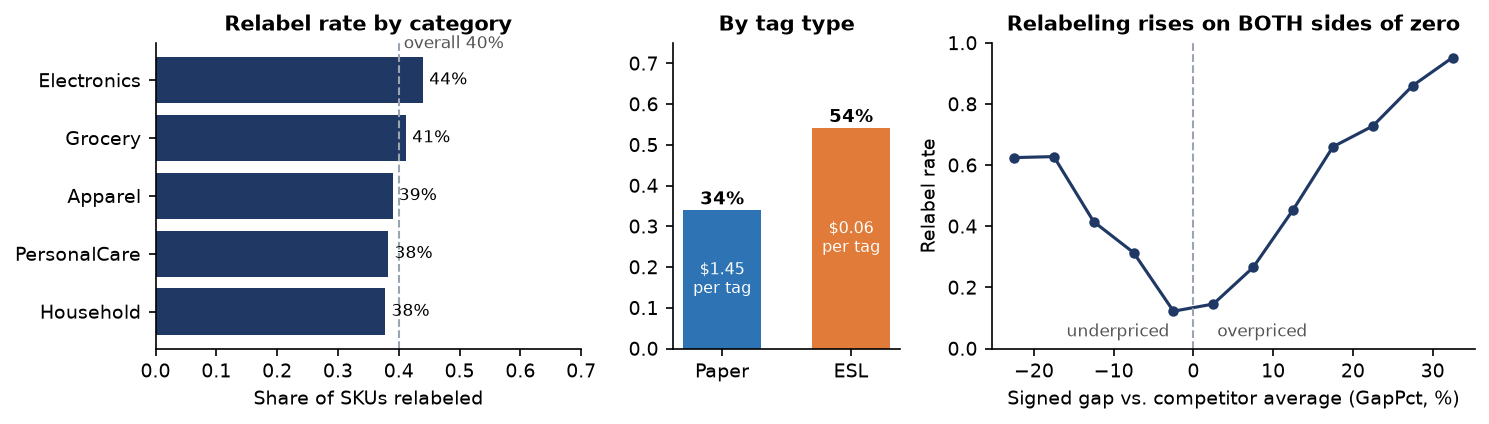

fig2_odds_ratios.png


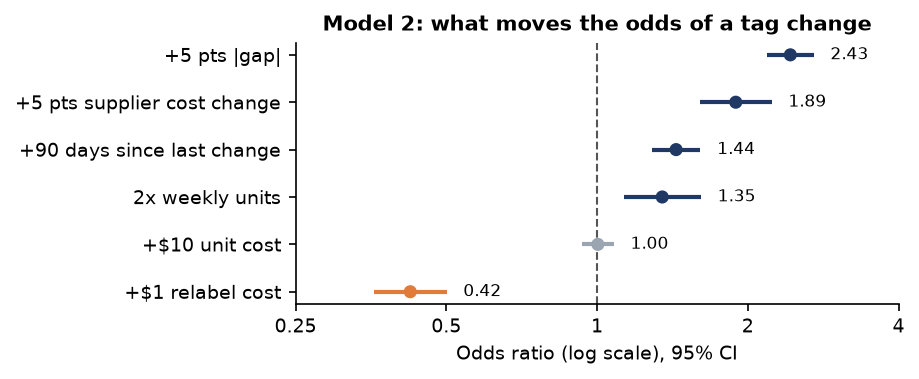

fig3_test_eval.png


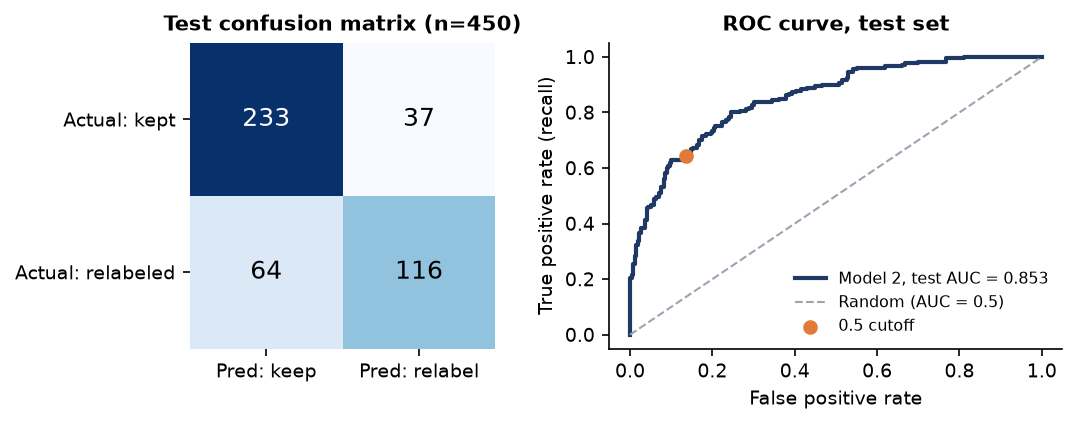

fig4_net_benefit.png


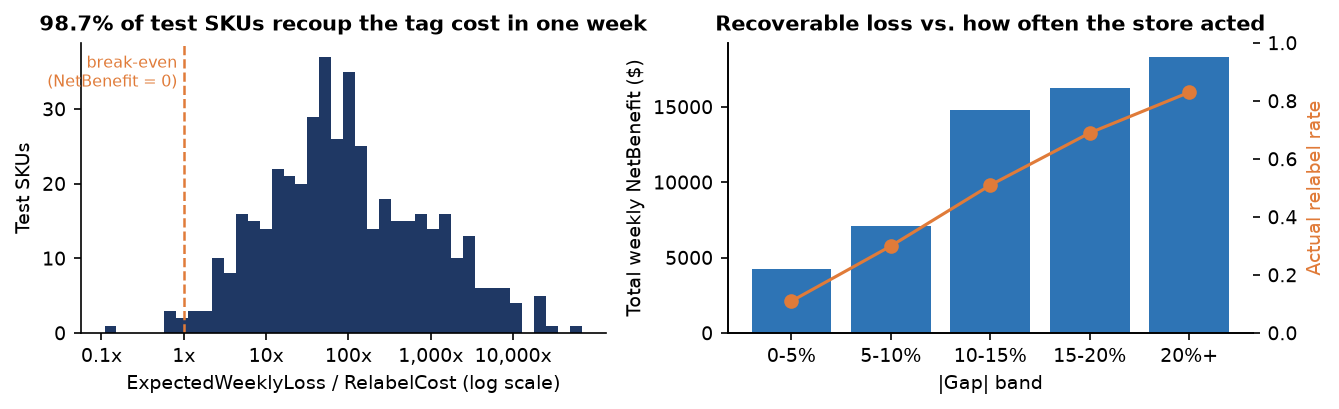

In [16]:
from IPython.display import Image, display
for p in sorted(FIG.glob('*.png')):
    print(p.name); display(Image(filename=str(p)))